# Parametric Rainfall Insurance — Stochastic Loss Simulation for Weather-Linked Products
### Rainfall Distribution

This is the first notebook of the project **"Parametric Rainfall Insurance — Stochastic Loss Simulation for Weather-Linked Products"**

This notebook attempts to fit a distribution to the daily rainfall data. The data used here is the Miami, FL station's daily weather data taken for the past 30 years from 1995 to 2024. Given that most days will have 0 precipitaion (point mass at 0), we attempt to fit a Tweedie distirbution and a Gamma distribution to check which fits better. Parameters of the distribution are estimated using method of moments.

Bootstrapped K-S test is used to confirm that Tweedie distribution fits the precipitation data well. 

In [1]:
#Import necessary libraries
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from tweedie import tweedie
from scipy.stats import kstest
import datetime

In [2]:
#Load the rainfall data
rainfall_data = pd.read_csv("00_RainfallData_MiamiFL.csv")

#Update the database since -99.99 and -99.9 are missing values (remove from analysis)
rainfall_data = rainfall_data[(rainfall_data[' PRECIPITATION']!=-99.99) & (rainfall_data[' PRECIPITATION']!=-99.9)]

#Date columns added for time series
rainfall_data[' DATE'] = rainfall_data.apply(lambda x: datetime.date(int(x[' YEAR']), int(x[' MONTH']), int(x[' DAY'])), axis=1)
rainfall_data[' DATE'] = pd.to_datetime(rainfall_data[' DATE'])
rainfall_data[' DAY_OF_YEAR'] = rainfall_data[' DATE'].dt.day_of_year

In [3]:
#Average Daily Rainfall across all years
daily_average_rainfall = rainfall_data.groupby([' MONTH',' DAY'])[' PRECIPITATION'].mean().reset_index()
daily_average_rainfall[' DAY_OF_YEAR'] = np.arange(1,367,1)
daily_average_rainfall = daily_average_rainfall.rename(columns={' PRECIPITATION':' AVG_RAINFALL'})

#Final Dataframe
rainfall_data = rainfall_data.merge(daily_average_rainfall[[' AVG_RAINFALL',' DAY_OF_YEAR']], left_on=' DAY_OF_YEAR', right_on=' DAY_OF_YEAR')

In [4]:
#Sample Mean, Variance and Skewness
data_mean = rainfall_data[' PRECIPITATION'].mean()
data_var = rainfall_data[' PRECIPITATION'].var()
data_skew = rainfall_data[' PRECIPITATION'].skew()

In [26]:
# Grid search for power parameter using KS statistic (Minimize the KS Statistic)
p_grid = np.arange(1.50, 2, 0.05)
ks_stats = []

for p_candidate in p_grid:
    phi_candidate = data_var / (data_mean ** p_candidate)
    cdf = lambda v: tweedie.cdf(v, p=p_candidate, mu=data_mean, phi=phi_candidate)
    D = kstest(rainfall_data[' PRECIPITATION'], cdf).statistic
    ks_stats.append(D)

p_est = p_grid[np.argmin(ks_stats)]
phi_est = data_var / (data_mean ** p_est)

if __name__=='__main__':
    print(f"Optimal p: {p_est:.2f}, Corresponding phi: {phi_est:.4f}")

Optimal p: 1.90, Corresponding phi: 8.0756


In [27]:
#Parameters of the Tweedie Distribution using method of moments
mu_est = data_mean
p_est = p_est # p tested between 1.5 and 1.99; p=1.90 minimised KS statistic
phi_est = data_var/((data_mean**p_est))

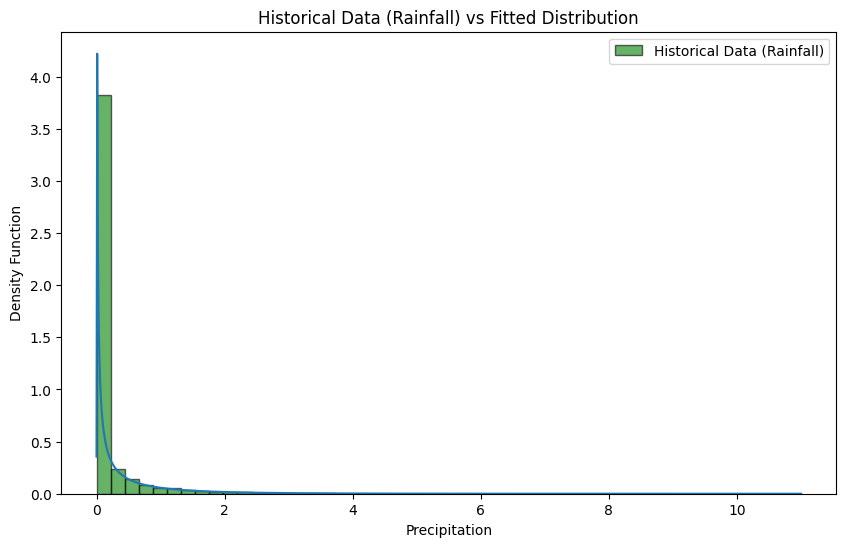

In [29]:
#Plot the empirical PDF of tweedie distribution on the histogram of actual data
if __name__=='__main__':
    x = np.linspace(min(rainfall_data[' PRECIPITATION']),max(rainfall_data[' PRECIPITATION']),num=1000)
    tweedie_pdf = tweedie.pdf(x,p=p_est, mu=mu_est,phi=phi_est)
    plt.figure(figsize=(10,6))
    plt.hist(rainfall_data[' PRECIPITATION'],bins=50, density=True, alpha=0.6, color='g', label='Historical Data (Rainfall)', edgecolor='black')
    plt.plot(x, tweedie_pdf)
    plt.title('Historical Data (Rainfall) vs Fitted Distribution')
    plt.legend()
    plt.xlabel('Precipitation')
    plt.ylabel('Density Function')


From the above plot, it seems like Tweedie distribution fits the rainfall data. The theoretical PDF does not seem to fit very well for the first bin but it could be because of the choice of the power parameter. The power parameter was selected after checking its sensitivity on this graph and K-S test. 

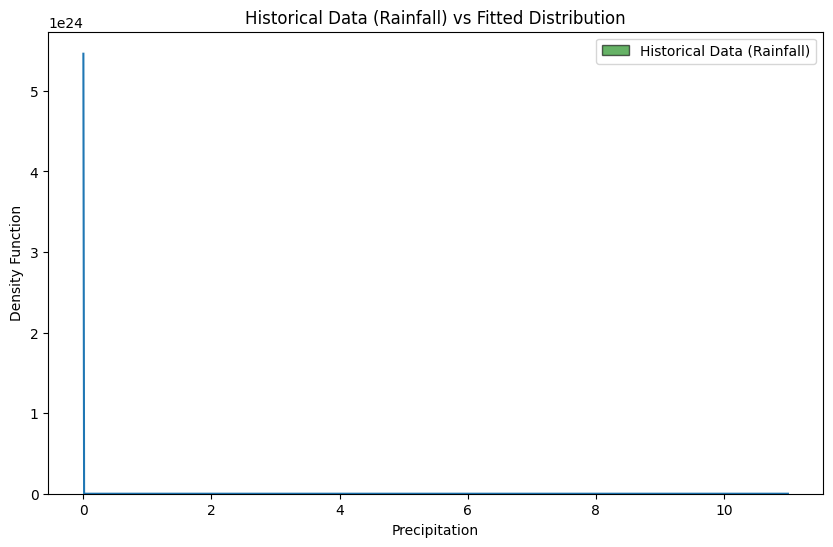

In [30]:
#Plot the empirical PDF of Gamma Distribution on the histogram of actual data
if __name__=='__main__':
    x = np.linspace(min(rainfall_data[' PRECIPITATION']),max(rainfall_data[' PRECIPITATION']),num=1000)
    alpha, loc, beta = stats.gamma.fit(rainfall_data[' PRECIPITATION'])
    gamma_pdf = stats.gamma.pdf(x,alpha,loc, beta)
    plt.figure(figsize=(10,6))
    plt.hist(rainfall_data[' PRECIPITATION'],bins=50, density=True, alpha=0.6, color='g', label='Historical Data (Rainfall)', edgecolor='black')
    plt.plot(x, gamma_pdf)
    plt.title('Historical Data (Rainfall) vs Fitted Distribution')
    plt.legend()
    plt.xlabel('Precipitation')
    plt.ylabel('Density Function')

The Gamma distribution struggles to fit the rainfall data because it cannot assign probability mass to exactly zero — all dry days are treated as very small positive values rather than true zeros. This is a fundamental limitation of the Gamma distribution for precipitation data.

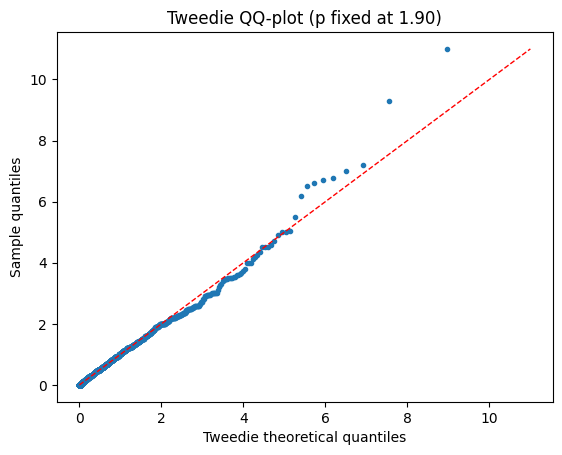

In [32]:
#Plot the QQ plot for the Tweedie distribution
if __name__=='__main__':
    #Function for QQ Plot of Tweedie
    def qqplot_tweedie(y, p, mu, phi):
        y = np.sort(np.asarray(y))
        n = len(y)
        u = (np.arange(1, n+1) - 0.5) / n
        x_theory = tweedie.ppf(u, p=p, mu=mu, phi=phi)
        plt.plot(x_theory, y, 'o', ms=3)
        m = max(x_theory.max(), y.max())
        plt.plot([0,m],[0,m], 'r--', lw=1)
        plt.xlabel('Tweedie theoretical quantiles')
        plt.ylabel('Sample quantiles')
        plt.title('Tweedie QQ-plot (p fixed at 1.90)')
        plt.show()
    qqplot_tweedie(rainfall_data[' PRECIPITATION'], p_est, mu_est, phi_est)

The sample quantiles and theoretical quantiles seem to lie on the 45 degree line at least for the lower quantiles. In the tails, there may be deviance and Tweedie distribution may be overestimating the tails.

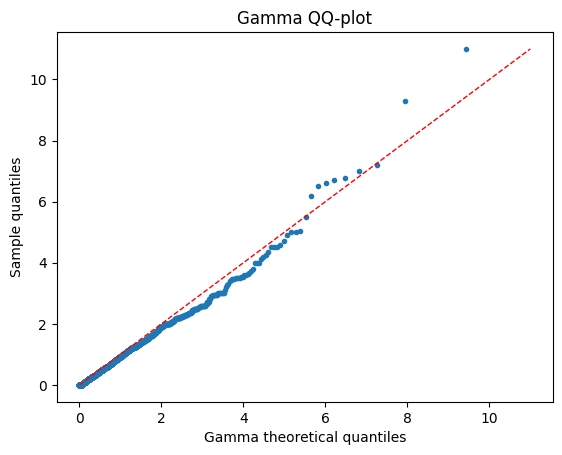

In [33]:
#Plot the QQ plot for Gamma
if __name__=='__main__':
    #Function for QQ Plot for Gamma
    def qqplot_gamma(y, alpha, loc, beta):
        y = np.sort(np.asarray(y))
        n = len(y)
        u = (np.arange(1, n+1) - 0.5) / n
        x_theory = stats.gamma.ppf(u, alpha, loc, beta)
        plt.plot(x_theory, y, 'o', ms=3)
        m = max(x_theory.max(), y.max())
        plt.plot([0,m],[0,m], 'r--', lw=1)
        plt.xlabel('Gamma theoretical quantiles')
        plt.ylabel('Sample quantiles')
        plt.title('Gamma QQ-plot')
        plt.show()
    qqplot_gamma(rainfall_data[' PRECIPITATION'], alpha, loc, beta)

The sample quantiles and theoretical quantiles seem to lie on the 45 degree line onlt for very low quantiles. Overall, does not look like a very bad fit but Tweedie distribution fits better. 

We can confirm that Tweedie distribution is a better fit than Gamma Distribution for precipitation data. 

In [34]:
#Perform Bootstrapped K-S Test to check if Tweedie fits well
if __name__=='__main__':
    
    #Function 1 - to fit tweedie
    def fit_mu_phi_mom(y, p):
        mu = np.mean(y)
        s2 = np.var(y)
        phi = s2 / (mu**p)
        return mu, phi

    #KS Test Statistic
    def ks_statistic(y, p, mu, phi):
        cdf = lambda v: tweedie.cdf(v, p=p, mu=mu, phi=phi)
        D = kstest(y, cdf).statistic
        return D

    #Bootstrap KS Values
    def bootstrap_ks_pvalue(y, p, mu_est, phi_est, B=500, random_state=42):
        rng = np.random.default_rng(random_state)

        # 1. Compute observed KS statistic
        D_obs = ks_statistic(y, p, mu_est, phi_est)

        # 2. Initialize counter
        count = 0
        n = len(y)

        for _ in range(B):
            # 3. Simulate bootstrap sample from fitted model
            yb = tweedie.rvs(p=p, mu=mu_est, phi=phi_est, size=n, random_state=rng)

            # 4. Refit parameters on bootstrap sample
            mu_b, phi_b = fit_mu_phi_mom(yb, p)

            # 5. Compute KS statistic for bootstrap sample
            D_b = ks_statistic(yb, p, mu_b, phi_b)

            # 7. Count if bootstrap statistic >= observed
            if D_b >= D_obs:
                count += 1

        # 8. Compute bootstrap p-value
        pval = (count + 1) / (B + 1)  # smoothed estimate
        return D_obs, pval


In [35]:
#p-value of the K-S test
if __name__=='__main__':
    print(f"The p-value is: {bootstrap_ks_pvalue(rainfall_data[' PRECIPITATION'], p=p_est, mu_est=mu_est, phi_est=phi_est,B=1000)[1]}")

The p-value is: 0.4835164835164835


The p-value is greater than 5% which means we have insufficient evidence to reject the null hypothesis that Tweedie distribution is a good fit. We proceed with our modelling using this fitted Tweedie Distribution. One limitation of this exercise is that we have not checked the Anderson-Darling GoF test results, since that is better suited for heavy-tailed distribution like Tweedie.

### End of Notebook